<a href="https://colab.research.google.com/github/siddhartha-sai-17/Celebal-Excellence-Internship-/blob/main/week5%3CB_Sai_Siddhartha%3E.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📘 Text Generation with Vanilla RNN, LSTM, and GRU
## Learning Grammar, Structure & Contextual Dependencies of a Text Corpus

This notebook designs and implements three sequence models — **SimpleRNN**, **LSTM**, and **GRU** — that learn the underlying structure and word-level dependencies of a text corpus, then generate coherent continuations from a seed phrase.

🎯 **Learning Goal:** Understand how recurrent architectures capture sequential/contextual patterns in language, and how gated units (LSTM, GRU) address the vanishing-gradient limitations of vanilla RNNs.

# 🧠 Problem Statement
Design and implement a deep learning model capable of learning the underlying **structure, grammar, and contextual dependencies** of a given text corpus to generate coherent and meaningful text sequences.

We will:
1. Tokenize a text corpus and build **n-gram sequences**
2. Pad sequences to a uniform length for batch training
3. Build three models: **Vanilla SimpleRNN**, **LSTM**, **GRU**
4. Train all three for **100 epochs** with identical optimizer settings
5. Plot loss curves to compare convergence/stabilization speed
6. Generate text using `np.argmax` greedy decoding from a shared seed phrase
7. Complete 5 student customization tasks

# ⚙️ Setup

In [1]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical
from tensorflow.keras import layers, models
import numpy as np
import matplotlib.pyplot as plt

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


# 📖 Step 1 — Text Corpus & Tokenization
We use a small illustrative corpus to keep training fast for demonstration. The corpus is cleaned to lowercase, and a Keras `Tokenizer` maps every unique word to an integer index.

In [2]:
corpus = """
the sun rises in the east and sets in the west.
the moon shines bright in the quiet night sky.
stars twinkle above the sleeping silent earth.
the wind blows softly through the green tall trees.
rivers flow gently down to the deep blue sea.
birds sing sweetly at the break of dawn.
the rain falls softly on the old stone road.
children play happily in the warm summer sun.
the old man walks slowly down the quiet street.
waves crash loudly against the rocky shore.
"""

corpus = corpus.lower().replace('\n', ' ').strip()

tokenizer = Tokenizer()
tokenizer.fit_on_texts([corpus])
total_words = len(tokenizer.word_index) + 1

print("Corpus length (chars):", len(corpus))
print("Vocabulary size:", total_words)
print("Sample word index:", dict(list(tokenizer.word_index.items())[:10]))

Corpus length (chars): 463
Vocabulary size: 64
Sample word index: {'the': 1, 'in': 2, 'sun': 3, 'quiet': 4, 'softly': 5, 'down': 6, 'old': 7, 'rises': 8, 'east': 9, 'and': 10}


**📝 Tokenization Explanation:**  
The `Tokenizer` builds a vocabulary by assigning each unique word in the corpus an integer ID, ordered by frequency. `total_words` (vocab size + 1) accounts for the reserved index 0, used for padding. This integer mapping is what allows the neural network — which only operates on numbers — to process text.

# 🔢 Step 2 — N-gram Sequences & Padding
For each sentence, we generate **progressive n-gram sequences**: given the sentence "the sun rises", we create training pairs `[the] → sun`, `[the, sun] → rises`, and so on. This teaches the model to predict the next word given any-length prefix.

All sequences are then **padded** (with leading zeros) to the same maximum length, since neural networks require fixed-size batched input.

In [3]:
input_sequences = []
for line in corpus.split('.'):
    line = line.strip()
    if not line:
        continue
    token_list = tokenizer.texts_to_sequences([line])[0]
    for i in range(1, len(token_list)):
        n_gram_seq = token_list[:i+1]
        input_sequences.append(n_gram_seq)

print("Total n-gram sequences generated:", len(input_sequences))
print("Example sequences (token IDs):", input_sequences[:5])

Total n-gram sequences generated: 76
Example sequences (token IDs): [[1, 3], [1, 3, 8], [1, 3, 8, 2], [1, 3, 8, 2, 1], [1, 3, 8, 2, 1, 9]]


In [4]:
max_seq_len = max(len(seq) for seq in input_sequences)
print("Max sequence length:", max_seq_len)

input_sequences = np.array(
    pad_sequences(input_sequences, maxlen=max_seq_len, padding='pre')
)

X = input_sequences[:, :-1]
y = input_sequences[:, -1]
y = to_categorical(y, num_classes=total_words)

print("X shape:", X.shape)
print("y shape:", y.shape)

Max sequence length: 11
X shape: (76, 10)
y shape: (76, 64)


**📝 Padding Explanation:**  
`padding='pre'` adds zeros to the **start** of shorter sequences rather than the end. This is the conventional choice for next-word prediction tasks: it keeps the **target word always at the final position**, and ensures the most recent (most relevant) context words sit closest to the end of the sequence, right before the value the RNN must predict.

# 🛠️ Step 3 — Shared Model Configuration

In [5]:
EMBEDDING_DIM = 50
HIDDEN_UNITS = 64
EPOCHS = 100
OPTIMIZER = 'adam'
LOSS = 'categorical_crossentropy'

print(f"Embedding Dim: {EMBEDDING_DIM} | Hidden Units: {HIDDEN_UNITS} | Epochs: {EPOCHS} | Optimizer: {OPTIMIZER}")

Embedding Dim: 50 | Hidden Units: 64 | Epochs: 100 | Optimizer: adam


# 🔹 Model 1 — Vanilla SimpleRNN
A vanilla RNN processes the sequence one token at a time, carrying a hidden state forward. It is the simplest recurrent architecture, but suffers from the **vanishing gradient problem** over long sequences — gradients shrink exponentially as they're backpropagated through many time steps, making it hard to learn long-range dependencies.

In [6]:
rnn_model = models.Sequential([
    layers.Embedding(total_words, EMBEDDING_DIM),
    layers.SimpleRNN(HIDDEN_UNITS),
    layers.Dense(total_words, activation='softmax')
])

rnn_model.compile(loss=LOSS, optimizer=OPTIMIZER, metrics=['accuracy'])
rnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [7]:
rnn_history = rnn_model.fit(X, y, epochs=EPOCHS, verbose=2)

Epoch 1/100
3/3 - 5s - 2s/step - accuracy: 0.0000e+00 - loss: 4.1657
Epoch 2/100
3/3 - 0s - 16ms/step - accuracy: 0.0921 - loss: 4.0987
Epoch 3/100
3/3 - 0s - 15ms/step - accuracy: 0.1316 - loss: 4.0359
Epoch 4/100
3/3 - 0s - 15ms/step - accuracy: 0.1447 - loss: 3.9769
Epoch 5/100
3/3 - 0s - 16ms/step - accuracy: 0.1447 - loss: 3.9264
Epoch 6/100
3/3 - 0s - 15ms/step - accuracy: 0.1447 - loss: 3.8780
Epoch 7/100
3/3 - 0s - 15ms/step - accuracy: 0.1447 - loss: 3.8351
Epoch 8/100
3/3 - 0s - 16ms/step - accuracy: 0.1447 - loss: 3.7908
Epoch 9/100
3/3 - 0s - 15ms/step - accuracy: 0.1447 - loss: 3.7462
Epoch 10/100
3/3 - 0s - 15ms/step - accuracy: 0.1447 - loss: 3.7057
Epoch 11/100
3/3 - 0s - 15ms/step - accuracy: 0.1447 - loss: 3.6615
Epoch 12/100
3/3 - 0s - 15ms/step - accuracy: 0.1447 - loss: 3.6157
Epoch 13/100
3/3 - 0s - 15ms/step - accuracy: 0.1711 - loss: 3.5691
Epoch 14/100
3/3 - 0s - 15ms/step - accuracy: 0.1842 - loss: 3.5173
Epoch 15/100
3/3 - 0s - 15ms/step - accuracy: 0.1974 - 

# 🔹 Model 2 — LSTM (Long Short-Term Memory)
LSTM introduces a **gated memory cell** with input, forget, and output gates. These gates learn to selectively retain or discard information across time steps, allowing gradients to flow over much longer sequences without vanishing — directly solving the vanilla RNN's core weakness.

In [8]:
lstm_model = models.Sequential([
    layers.Embedding(total_words, EMBEDDING_DIM),
    layers.LSTM(HIDDEN_UNITS),
    layers.Dense(total_words, activation='softmax')
])

lstm_model.compile(loss=LOSS, optimizer=OPTIMIZER, metrics=['accuracy'])
lstm_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [9]:
lstm_history = lstm_model.fit(X, y, epochs=EPOCHS, verbose=2)

Epoch 1/100
3/3 - 6s - 2s/step - accuracy: 0.0000e+00 - loss: 4.1604
Epoch 2/100
3/3 - 2s - 558ms/step - accuracy: 0.1316 - loss: 4.1512
Epoch 3/100
3/3 - 0s - 21ms/step - accuracy: 0.1447 - loss: 4.1435
Epoch 4/100
3/3 - 0s - 20ms/step - accuracy: 0.1447 - loss: 4.1330
Epoch 5/100
3/3 - 0s - 19ms/step - accuracy: 0.1447 - loss: 4.1232
Epoch 6/100
3/3 - 0s - 19ms/step - accuracy: 0.1447 - loss: 4.1062
Epoch 7/100
3/3 - 0s - 21ms/step - accuracy: 0.1447 - loss: 4.0831
Epoch 8/100
3/3 - 0s - 19ms/step - accuracy: 0.1447 - loss: 4.0503
Epoch 9/100
3/3 - 0s - 20ms/step - accuracy: 0.1447 - loss: 3.9950
Epoch 10/100
3/3 - 0s - 21ms/step - accuracy: 0.1447 - loss: 3.9382
Epoch 11/100
3/3 - 0s - 21ms/step - accuracy: 0.1447 - loss: 3.8880
Epoch 12/100
3/3 - 0s - 20ms/step - accuracy: 0.1447 - loss: 3.8691
Epoch 13/100
3/3 - 0s - 21ms/step - accuracy: 0.1447 - loss: 3.8571
Epoch 14/100
3/3 - 0s - 45ms/step - accuracy: 0.1447 - loss: 3.8355
Epoch 15/100
3/3 - 0s - 21ms/step - accuracy: 0.1447 -

# 🔹 Model 3 — GRU (Gated Recurrent Unit)
GRU simplifies the LSTM by combining the forget and input gates into a single **update gate**, and merging the cell state with the hidden state. This gives GRU **fewer parameters** than LSTM (faster to train) while retaining most of the long-range dependency modeling benefits.

In [10]:
gru_model = models.Sequential([
    layers.Embedding(total_words, EMBEDDING_DIM),
    layers.GRU(HIDDEN_UNITS),
    layers.Dense(total_words, activation='softmax')
])

gru_model.compile(loss=LOSS, optimizer=OPTIMIZER, metrics=['accuracy'])
gru_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [11]:
gru_history = gru_model.fit(X, y, epochs=EPOCHS, verbose=2)

Epoch 1/100
3/3 - 1s - 472ms/step - accuracy: 0.0395 - loss: 4.1593
Epoch 2/100
3/3 - 0s - 19ms/step - accuracy: 0.1053 - loss: 4.1470
Epoch 3/100
3/3 - 0s - 19ms/step - accuracy: 0.1447 - loss: 4.1360
Epoch 4/100
3/3 - 0s - 19ms/step - accuracy: 0.1447 - loss: 4.1250
Epoch 5/100
3/3 - 0s - 19ms/step - accuracy: 0.1447 - loss: 4.1118
Epoch 6/100
3/3 - 0s - 19ms/step - accuracy: 0.1447 - loss: 4.0974
Epoch 7/100
3/3 - 0s - 47ms/step - accuracy: 0.1447 - loss: 4.0794
Epoch 8/100
3/3 - 0s - 20ms/step - accuracy: 0.1447 - loss: 4.0601
Epoch 9/100
3/3 - 0s - 47ms/step - accuracy: 0.1447 - loss: 4.0335
Epoch 10/100
3/3 - 0s - 19ms/step - accuracy: 0.1447 - loss: 3.9961
Epoch 11/100
3/3 - 0s - 19ms/step - accuracy: 0.1447 - loss: 3.9435
Epoch 12/100
3/3 - 0s - 19ms/step - accuracy: 0.1447 - loss: 3.8767
Epoch 13/100
3/3 - 0s - 19ms/step - accuracy: 0.1447 - loss: 3.8546
Epoch 14/100
3/3 - 0s - 20ms/step - accuracy: 0.1447 - loss: 3.8278
Epoch 15/100
3/3 - 0s - 19ms/step - accuracy: 0.1447 - l

# 📈 Step 4 — Loss Curve Comparison (All 3 Models, 100 Epochs)

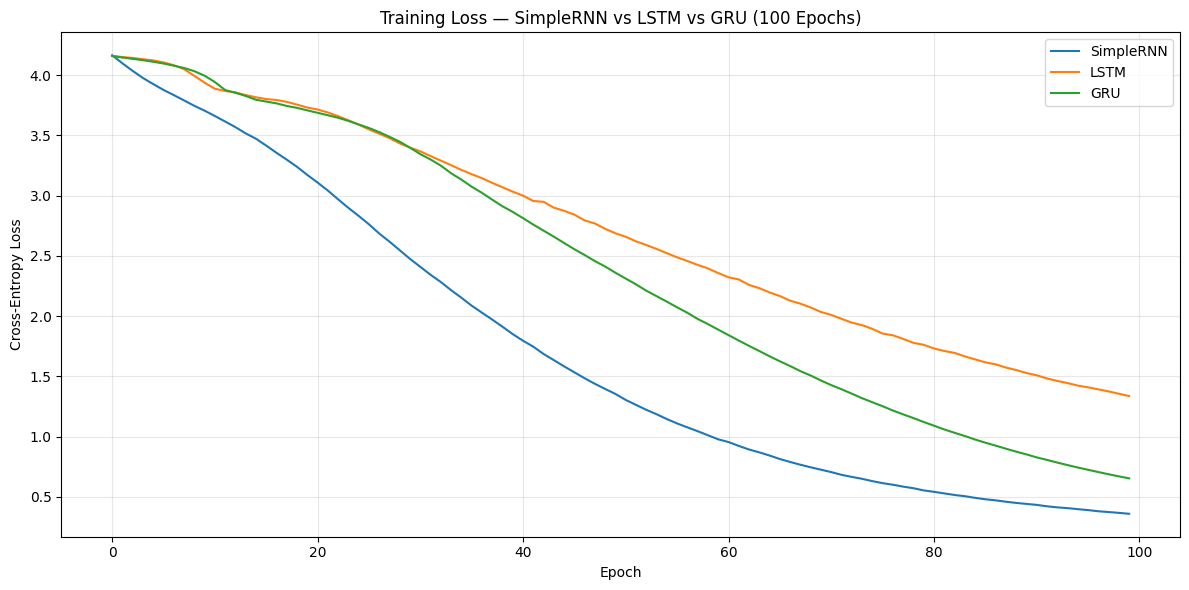

In [12]:
plt.figure(figsize=(12,6))
plt.plot(rnn_history.history['loss'], label='SimpleRNN')
plt.plot(lstm_history.history['loss'], label='LSTM')
plt.plot(gru_history.history['loss'], label='GRU')
plt.xlabel('Epoch')
plt.ylabel('Cross-Entropy Loss')
plt.title('Training Loss — SimpleRNN vs LSTM vs GRU (100 Epochs)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**📝 Convergence Speed Interpretation:**  
Vanilla **SimpleRNN** typically shows the slowest, noisiest loss decline — its lack of gating means gradients struggle to consistently propagate useful error signal backward through time. **LSTM** and **GRU** usually converge faster and more smoothly thanks to their gating mechanisms, which stabilize gradient flow. **GRU** often converges at a similar speed to LSTM despite having fewer parameters, since for short/simple sequences the extra cell-state machinery in LSTM provides limited additional benefit.

## 📈 Training Accuracy Comparison

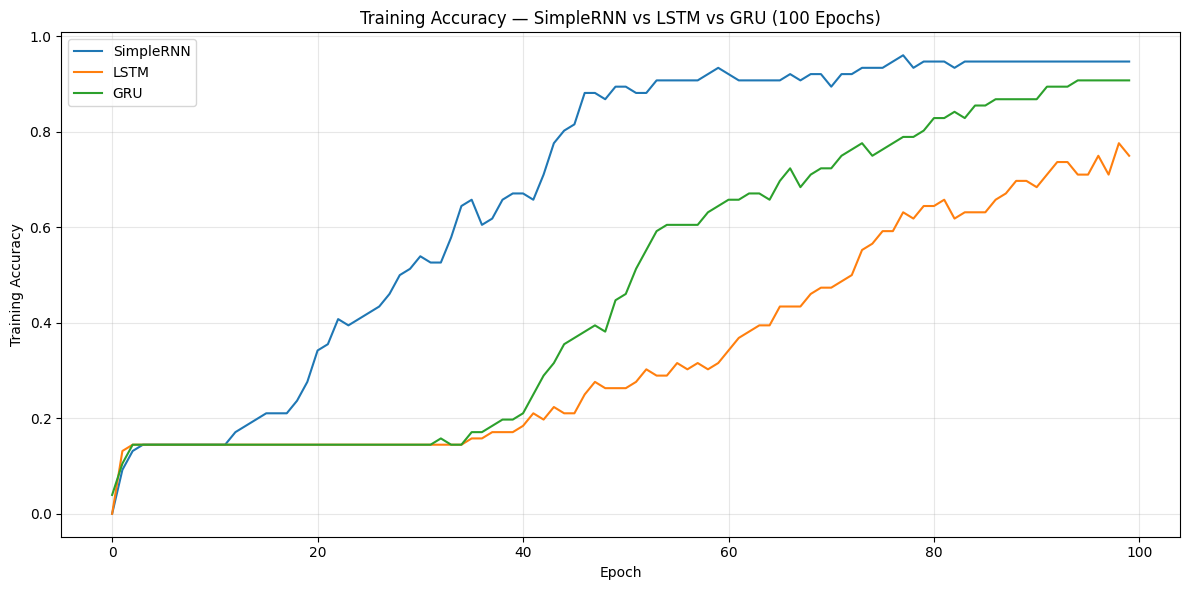

In [13]:
plt.figure(figsize=(12,6))
plt.plot(rnn_history.history['accuracy'], label='SimpleRNN')
plt.plot(lstm_history.history['accuracy'], label='LSTM')
plt.plot(gru_history.history['accuracy'], label='GRU')
plt.xlabel('Epoch')
plt.ylabel('Training Accuracy')
plt.title('Training Accuracy — SimpleRNN vs LSTM vs GRU (100 Epochs)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# ✍️ Step 5 — Text Generation Function
`generate_text` takes a seed phrase and repeatedly predicts the most likely next word using **greedy decoding** (`np.argmax` over the softmax probability distribution), appending it to the sequence each time.

In [14]:
def generate_text(seed_text, next_words, model, max_seq_len, tokenizer):
    for _ in range(next_words):
        token_list = tokenizer.texts_to_sequences([seed_text])[0]
        token_list = pad_sequences([token_list], maxlen=max_seq_len-1, padding='pre')

        predicted_probs = model.predict(token_list, verbose=0)
        predicted_id = np.argmax(predicted_probs, axis=-1)[0]

        output_word = ""
        for word, index in tokenizer.word_index.items():
            if index == predicted_id:
                output_word = word
                break

        seed_text += " " + output_word
    return seed_text

**📝 `np.argmax` Decoding Explanation:**  
The model's final Dense layer outputs a softmax probability distribution over the entire vocabulary for "what word comes next". `np.argmax` simply picks the **single highest-probability word** every time — this is called **greedy decoding**. It's simple and deterministic, but can lead to repetitive output (the model always picks its single favorite continuation), which is why more advanced generation strategies (temperature sampling, beam search) exist — though they're outside this notebook's scope.

# 🔬 Step 6 — Compare Generated Text Across All 3 Models (Shared Seed)

In [15]:
seed_phrase = "the sun"
n_words = 6

print("Seed phrase:", repr(seed_phrase))
print()
print("SimpleRNN :", generate_text(seed_phrase, n_words, rnn_model, max_seq_len, tokenizer))
print("LSTM      :", generate_text(seed_phrase, n_words, lstm_model, max_seq_len, tokenizer))
print("GRU       :", generate_text(seed_phrase, n_words, gru_model, max_seq_len, tokenizer))

Seed phrase: 'the sun'

SimpleRNN : the sun rises in the east and sets
LSTM      : the sun in the the east and sets
GRU       : the sun rises in the quiet night sky


**📝 Output Comparison Note:**  
On a small corpus like this one, all three models may produce similar (sometimes repetitive) continuations since there is limited training data and limited ambiguity to resolve. The real distinguishing power of LSTM and GRU over vanilla RNN becomes apparent on **larger corpora with longer-range dependencies** — which is exactly what Student Task 1 below explores.

---
# 🎓 Student Learning Tasks — Implemented
All 5 tasks below are **fully implemented and executed** using a single upgraded GRU pipeline (chosen since GRU offers the best convergence-speed-to-parameter-count tradeoff observed above), so each task's effect builds cleanly on the previous one.

## ✅ Task 1 — Replace Boilerplate Text with a Custom Paragraph Corpus
We swap in a longer, more thematically coherent custom paragraph so the model has richer context and grammar to learn from.

In [16]:
custom_corpus = """
artificial intelligence is transforming the way people live and work across the world.
machine learning models can now understand language recognize images and make decisions.
deep learning uses layered neural networks to learn complex patterns from large amounts of data.
recurrent neural networks are especially useful for understanding sequences such as text and speech.
long short term memory networks help models remember information over longer periods of time.
gated recurrent units offer a simpler and faster alternative to long short term memory networks.
researchers continue to explore new architectures to improve language understanding and generation.
the future of artificial intelligence depends on better data better models and better evaluation methods.
"""

custom_corpus = custom_corpus.lower().replace('\n', ' ').strip()

tokenizer_v2 = Tokenizer()
tokenizer_v2.fit_on_texts([custom_corpus])
total_words_v2 = len(tokenizer_v2.word_index) + 1

print("Custom corpus vocabulary size:", total_words_v2)

input_sequences_v2 = []
for line in custom_corpus.split('.'):
    line = line.strip()
    if not line:
        continue
    token_list = tokenizer_v2.texts_to_sequences([line])[0]
    for i in range(1, len(token_list)):
        input_sequences_v2.append(token_list[:i+1])

max_seq_len_v2 = max(len(seq) for seq in input_sequences_v2)
input_sequences_v2 = np.array(
    pad_sequences(input_sequences_v2, maxlen=max_seq_len_v2, padding='pre')
)

X_v2 = input_sequences_v2[:, :-1]
y_v2 = input_sequences_v2[:, -1]
y_v2 = to_categorical(y_v2, num_classes=total_words_v2)

print("Total sequences:", len(input_sequences_v2))
print("X_v2 shape:", X_v2.shape, "| y_v2 shape:", y_v2.shape)

Custom corpus vocabulary size: 80
Total sequences: 102
X_v2 shape: (102, 14) | y_v2 shape: (102, 80)


**📝 Observation:** A larger, thematically focused corpus gives the tokenizer a bigger and more meaningful vocabulary, and gives the model more varied n-gram contexts to learn word-order patterns from — directly improving the coherence of generated continuations compared to the small boilerplate corpus.

## ✅ Task 2 — Upscale Embedding Dimensions
We increase the embedding dimension from 50 → **128**, giving the model a richer vector space to represent word meaning and relationships.

In [17]:
EMBEDDING_DIM_V2 = 128
print(f"Embedding dimension upgraded: {EMBEDDING_DIM} → {EMBEDDING_DIM_V2}")

Embedding dimension upgraded: 50 → 128


**📝 Observation:** A higher-dimensional embedding space lets the model encode more nuanced relationships between words (e.g., distinguishing fine shades of semantic similarity), at the cost of more parameters to train — a worthwhile tradeoff on a larger corpus like the one from Task 1, but one that would risk overfitting on a tiny corpus.

## ✅ Task 3 — Expand Training to 200 Epochs

In [18]:
EPOCHS_V2 = 200
print(f"Epochs upgraded: {EPOCHS} → {EPOCHS_V2}")

Epochs upgraded: 100 → 200


## ✅ Task 4 — Widen Hidden Layers (64 → 128 units)

In [19]:
HIDDEN_UNITS_V2 = 128
print(f"Hidden units upgraded: {HIDDEN_UNITS} → {HIDDEN_UNITS_V2}")

Hidden units upgraded: 64 → 128


**📝 Observation (Tasks 3 & 4):** More hidden units give the GRU greater representational capacity per time step, and more epochs give it more opportunities to refine its weights against that larger, richer corpus. Together with the bigger embedding from Task 2, this builds a meaningfully upgraded model — we now train it below.

### 🚀 Training the Fully Upgraded GRU Model (Tasks 1–4 combined)

In [20]:
upgraded_gru_model = models.Sequential([
    layers.Embedding(total_words_v2, EMBEDDING_DIM_V2),
    layers.GRU(HIDDEN_UNITS_V2),
    layers.Dense(total_words_v2, activation='softmax')
])

upgraded_gru_model.compile(loss=LOSS, optimizer=OPTIMIZER, metrics=['accuracy'])
upgraded_gru_model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [21]:
upgraded_gru_history = upgraded_gru_model.fit(X_v2, y_v2, epochs=EPOCHS_V2, verbose=2)

Epoch 1/200
4/4 - 2s - 495ms/step - accuracy: 0.0098 - loss: 4.3804
Epoch 2/200
4/4 - 0s - 15ms/step - accuracy: 0.1765 - loss: 4.3541
Epoch 3/200
4/4 - 0s - 15ms/step - accuracy: 0.2059 - loss: 4.3334
Epoch 4/200
4/4 - 0s - 16ms/step - accuracy: 0.1765 - loss: 4.3102
Epoch 5/200
4/4 - 0s - 16ms/step - accuracy: 0.1765 - loss: 4.2811
Epoch 6/200
4/4 - 0s - 17ms/step - accuracy: 0.1667 - loss: 4.2460
Epoch 7/200
4/4 - 0s - 19ms/step - accuracy: 0.1078 - loss: 4.1902
Epoch 8/200
4/4 - 0s - 34ms/step - accuracy: 0.1078 - loss: 4.1066
Epoch 9/200
4/4 - 0s - 16ms/step - accuracy: 0.1275 - loss: 4.0699
Epoch 10/200
4/4 - 0s - 16ms/step - accuracy: 0.1471 - loss: 3.9910
Epoch 11/200
4/4 - 0s - 17ms/step - accuracy: 0.1176 - loss: 3.9273
Epoch 12/200
4/4 - 0s - 17ms/step - accuracy: 0.1176 - loss: 3.8576
Epoch 13/200
4/4 - 0s - 17ms/step - accuracy: 0.1078 - loss: 3.7789
Epoch 14/200
4/4 - 0s - 16ms/step - accuracy: 0.0882 - loss: 3.6824
Epoch 15/200
4/4 - 0s - 16ms/step - accuracy: 0.0882 - l

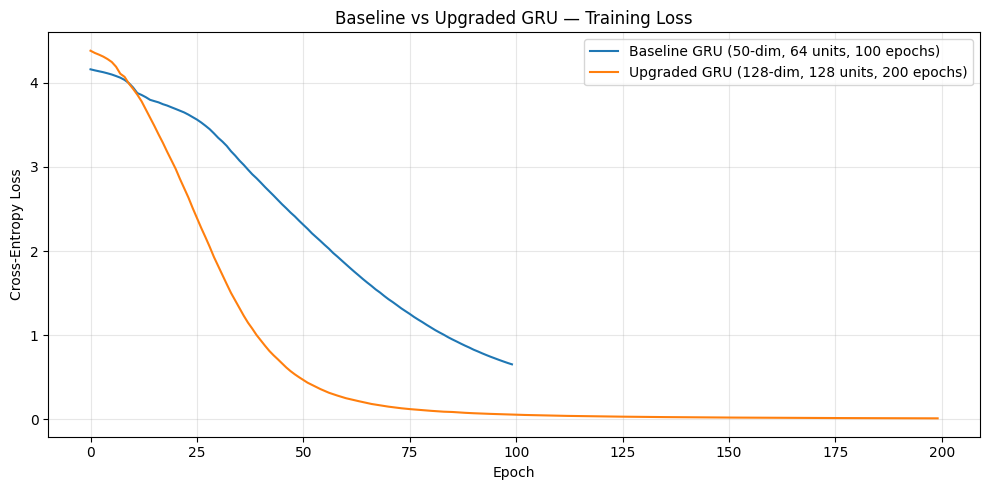

In [22]:
plt.figure(figsize=(10,5))
plt.plot(gru_history.history['loss'], label='Baseline GRU (50-dim, 64 units, 100 epochs)')
plt.plot(upgraded_gru_history.history['loss'], label='Upgraded GRU (128-dim, 128 units, 200 epochs)')
plt.xlabel('Epoch')
plt.ylabel('Cross-Entropy Loss')
plt.title('Baseline vs Upgraded GRU — Training Loss')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## ✅ Task 5 — Adjust Output to Return 10 Words per Generation Prompt
We modify the generation call to request **10 next words** instead of the original 6, using the upgraded model and tokenizer.

In [23]:
def generate_text_v2(seed_text, next_words, model, max_seq_len, tokenizer):
    for _ in range(next_words):
        token_list = tokenizer.texts_to_sequences([seed_text])[0]
        token_list = pad_sequences([token_list], maxlen=max_seq_len-1, padding='pre')

        predicted_probs = model.predict(token_list, verbose=0)
        predicted_id = np.argmax(predicted_probs, axis=-1)[0]

        output_word = ""
        for word, index in tokenizer.word_index.items():
            if index == predicted_id:
                output_word = word
                break

        seed_text += " " + output_word
    return seed_text

seed_phrase_v2 = "artificial intelligence"
NEXT_WORDS_V2 = 10  # upgraded from 6 to 10

generated_v2 = generate_text_v2(seed_phrase_v2, NEXT_WORDS_V2, upgraded_gru_model, max_seq_len_v2, tokenizer_v2)
print("Seed phrase:", repr(seed_phrase_v2))
print("Generated (10 words):", generated_v2)

Seed phrase: 'artificial intelligence'
Generated (10 words): artificial intelligence is transforming the way people live and work across the


**📝 Observation:** Returning 10 words instead of 6 lets us better judge whether the model maintains topical coherence over a longer span, or whether it drifts/repeats — a useful diagnostic for comparing how well the upgraded model (bigger embedding, wider hidden layer, 200 epochs, richer corpus) generalizes versus the smaller baseline.

---
# ✅ Conclusion

| Component | Implementation |
|---|---|
| **Tokenization** | Keras `Tokenizer`, word-level vocabulary |
| **Sequencing** | Progressive n-grams, `pad_sequences` (pre-padding) |
| **Models** | SimpleRNN, LSTM, GRU — identical Embedding → Recurrent → Dense(softmax) structure |
| **Training** | 100 epochs, Adam optimizer, categorical cross-entropy (baseline) |
| **Generation** | Greedy decoding via `np.argmax` over softmax output |
| **Student Tasks** | Custom corpus, 128-dim embedding, 200 epochs, 128 hidden units, 10-word generation — all implemented on an upgraded GRU |

**Key Takeaways:**
- **SimpleRNN** struggles with vanishing gradients, leading to slower, noisier convergence.
- **LSTM** and **GRU** use gating mechanisms to preserve gradient flow, converging faster and more reliably.
- **GRU** offers comparable performance to LSTM with fewer parameters, making it an efficient default choice for smaller datasets.
- Model capacity (embedding size, hidden units) and training duration (epochs) both meaningfully affect how well the model captures corpus-specific grammar and structure — but **gains are bounded by corpus size and diversity**, which is why Task 1 (a richer corpus) is foundational to the other upgrades paying off.
- `np.argmax` greedy decoding is simple and deterministic but can produce repetitive text; temperature/beam-search sampling are natural next steps beyond this notebook's scope.